In [13]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as sch
import seaborn as sns
import riskfolio as rp
from scipy.spatial.distance import squareform
import warnings
warnings.filterwarnings("ignore")
pd.options.display.float_format = '{:.4%}'.format

In [15]:
# ── Tickers ──────────────────────────────────────────────────────────────
indian_tickers = ['RELIANCE.NS','ICICIBANK.NS','LT.NS','BHARTIARTL.NS',
                  'INFY.NS','TCS.NS','TITAN.NS','ASIANPAINT.NS','NESTLEIND.NS',
                  'PAGEIND.NS','HDFCBANK.NS','ULTRACEMCO.NS','DIVISLAB.NS']
us_tickers     = ['AAPL','MSFT','JPM','NVDA','GOOGL','AMZN','META','UNH','V','MA',
                  'KO','PFE','XOM','CSCO','PG','MCD','TEVA','NICE','SPGI','TLT','LQD','BBUS']
japan_tickers  = ['7203.T','6758.T','7974.T']
taiwan_tickers = ['TSM']
fx_tickers     = ['USDINR=X','JPYINR=X','TWDINR=X']

start_date, end_date = '2018-01-01', '2025-06-10'

# ── Download ──────────────────────────────────────────────────────────────
prices_india = yf.download(indian_tickers, start=start_date, end=end_date)['Close']
prices_us    = yf.download(us_tickers,     start=start_date, end=end_date)['Close']
prices_jp    = yf.download(japan_tickers,  start=start_date, end=end_date)['Close']
prices_tw    = yf.download(taiwan_tickers, start=start_date, end=end_date)['Close']
fx_data      = yf.download(fx_tickers,     start=start_date, end=end_date)['Close']
benchmark    = yf.download('^NSEI',        start=start_date, end=end_date)['Close']

# ── Step 1: Build a common business-day index ─────────────────────────────
all_dates  = (prices_india.index
              .union(prices_us.index)
              .union(prices_jp.index)
              .union(prices_tw.index))
bday_index = all_dates[all_dates.weekday < 5]

# ── Step 2: Reindex everything to the common calendar, then ffill ─────────
def align(df):
    return df.reindex(bday_index).ffill().bfill()

prices_india = align(prices_india)
prices_us    = align(prices_us)
prices_jp    = align(prices_jp)
prices_tw    = align(prices_tw)
fx_data      = align(fx_data)

# ── Step 3: FX conversion ─────────────────────────────────────────────────
prices_us_inr = prices_us.multiply(fx_data['USDINR=X'], axis=0)
prices_jp_inr = prices_jp.multiply(fx_data['JPYINR=X'], axis=0)
prices_tw_inr = prices_tw.multiply(fx_data['TWDINR=X'], axis=0)

# ── Step 4: Combine ───────────────────────────────────────────────────────
prices_inr = pd.concat([prices_india, prices_us_inr, prices_jp_inr, prices_tw_inr], axis=1)

# Keep a raw copy for coverage diagnostics
prices_inr_raw = prices_inr.copy()

# ── Step 5: Column quality filter (drop sparse assets) ────────────────────
cols_before = set(prices_inr.columns)
min_obs     = int(0.80 * len(prices_inr))
prices_inr  = prices_inr.dropna(axis=1, thresh=min_obs)
cols_after  = set(prices_inr.columns)

removed_step5 = cols_before - cols_after
print(f"\nStep 5 — Assets removed (< 80% price coverage): {len(removed_step5)}")
for c in sorted(removed_step5):
    pct = prices_inr_raw[c].notna().mean() * 100
    print(f"   ✗ {c:20s}  coverage: {pct:.1f}%")

# ── Step 6: Row quality filter ────────────────────────────────────────────
rows_before = len(prices_inr)
min_assets  = int(0.80 * prices_inr.shape[1])
prices_inr  = prices_inr.dropna(thresh=min_assets)
rows_after  = len(prices_inr)

print(f"\nStep 6 — Rows removed (< 80% assets present): "
      f"{rows_before - rows_after}  ({rows_before} → {rows_after})")

# ── Step 7: Final ffill + dropna ──────────────────────────────────────────
cols_before2 = set(prices_inr.columns)
rows_before2 = len(prices_inr)

prices_inr = prices_inr.ffill().dropna()

removed_step7 = cols_before2 - set(prices_inr.columns)
print(f"\nStep 7 — After final ffill + dropna:")
print(f"   Rows removed : {rows_before2 - len(prices_inr)}")
print(f"   Cols removed : {sorted(removed_step7) if removed_step7 else 'none'}")
print(f"\nprices_inr shape : {prices_inr.shape}")
print(f"   Date range        : {prices_inr.index[0].date()} → {prices_inr.index[-1].date()}")

# ── Step 8: Returns ───────────────────────────────────────────────────────
returns_inr = prices_inr.pct_change().dropna()

# ── Step 9: Safe standardization ─────────────────────────────────────────
means = returns_inr.mean()
stds  = returns_inr.std()

dead_cols = stds[stds < 1e-10].index.tolist()
if dead_cols:
    print(f"\nStep 9 — Zero-std assets dropped: {dead_cols}")
    returns_inr = returns_inr.drop(columns=dead_cols)
    means       = means.drop(dead_cols)
    stds        = stds.drop(dead_cols)

returns_std = (returns_inr - means) / stds

# ── Step 10: Correlation + symmetric distance matrix ─────────────────────
correlation = returns_std.corr()
correlation = (correlation + correlation.T) / 2
correlation = correlation.clip(-1, 1)
np.fill_diagonal(correlation.values, 1.0)

distance = np.sqrt(0.5 * (1 - correlation))
distance  = (distance + distance.T) / 2
np.fill_diagonal(distance.values, 0.0)

assert np.allclose(distance, distance.T, atol=1e-10), "Distance matrix not symmetric!"

# ── Step 11: HRP clustering ───────────────────────────────────────────────
condensed  = squareform(distance.values)
link       = sch.linkage(condensed, method='ward')
leaf_order = sch.leaves_list(link)

# ── Final summary ─────────────────────────────────────────────────────────
all_input   = set(indian_tickers + us_tickers + japan_tickers + taiwan_tickers)
all_kept    = set(returns_inr.columns)
all_removed = all_input - all_kept

print(f"\n{'='*55}")
print(f"ASSET FILTER SUMMARY")
print(f"{'='*55}")
print(f"  Started with : {len(all_input)} assets")
print(f"  Kept         : {len(all_kept)} assets")
print(f"  Removed      : {len(all_removed)} assets")
print(f"\n  Removed tickers:")
for t in sorted(all_removed):
    print(f"    ✗ {t}")
print(f"\n  Kept tickers:")
for t in sorted(all_kept):
    print(f"    ✓ {t}")
print(f"{'='*55}")
print(f"\nreturns_std shape : {returns_std.shape}")
print(f"Symmetry check passed — ready for HRP")

[*********************100%***********************]  13 of 13 completed
[*********************100%***********************]  22 of 22 completed
[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  1 of 1 completed


Step 5 — Assets removed (< 80% price coverage): 0

Step 6 — Rows removed (< 80% assets present): 0  (1941 → 1941)

Step 7 — After final ffill + dropna:
   Rows removed : 0
   Cols removed : none

prices_inr shape : (1941, 39)
   Date range        : 2018-01-01 → 2025-06-09

ASSET FILTER SUMMARY
  Started with : 39 assets
  Kept         : 39 assets
  Removed      : 0 assets

  Removed tickers:

  Kept tickers:
    ✓ 6758.T
    ✓ 7203.T
    ✓ 7974.T
    ✓ AAPL
    ✓ AMZN
    ✓ ASIANPAINT.NS
    ✓ BBUS
    ✓ BHARTIARTL.NS
    ✓ CSCO
    ✓ DIVISLAB.NS
    ✓ GOOGL
    ✓ HDFCBANK.NS
    ✓ ICICIBANK.NS
    ✓ INFY.NS
    ✓ JPM
    ✓ KO
    ✓ LQD
    ✓ LT.NS
    ✓ MA
    ✓ MCD
    ✓ META
    ✓ MSFT
    ✓ NESTLEIND.NS
    ✓ NICE
    ✓ NVDA
    ✓ PAGEIND.NS
    ✓ PFE
    ✓ PG
    ✓ RELIANCE.NS
    ✓ SPGI
    ✓ TCS.NS
    ✓ TEVA
    ✓ TITAN.NS
    ✓ TLT
    ✓ TSM
    ✓ ULTRACEMCO.NS
    ✓ UNH
    ✓ V
    ✓ XOM

returns_std shape : (1940, 39)
Symmetry check passed — ready for HRP


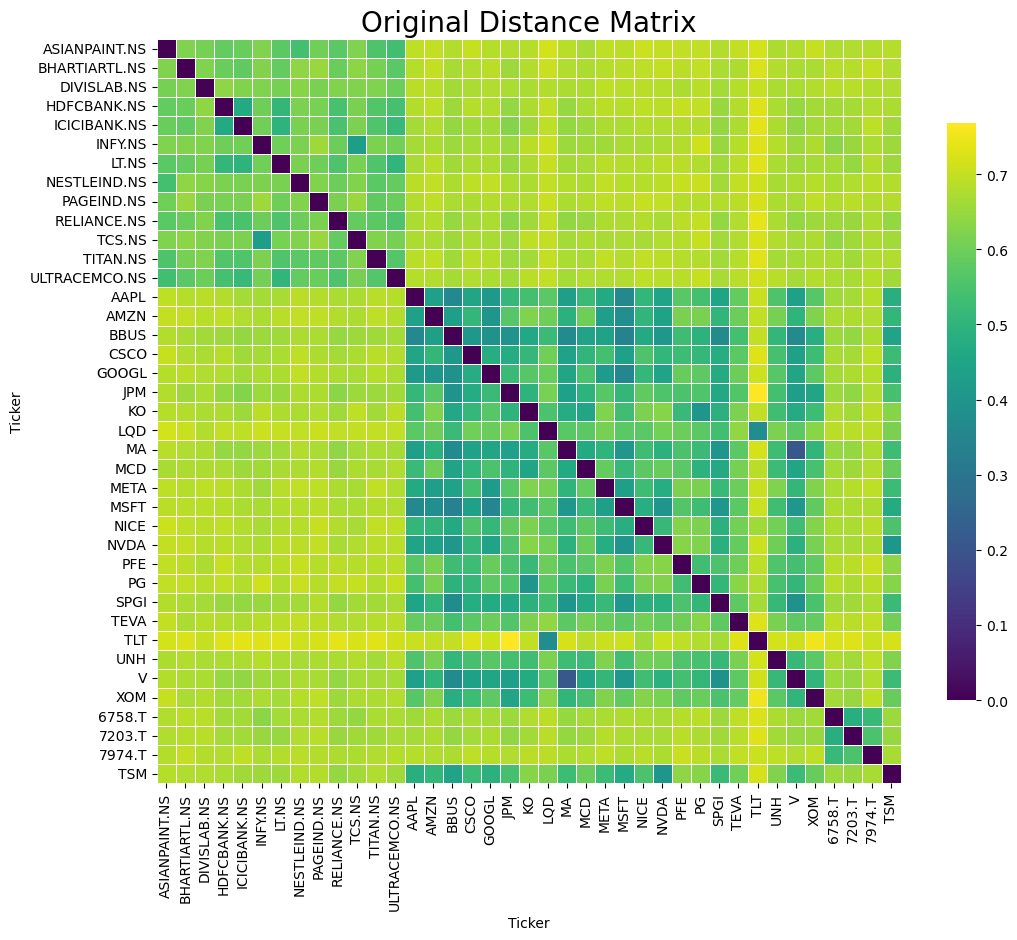

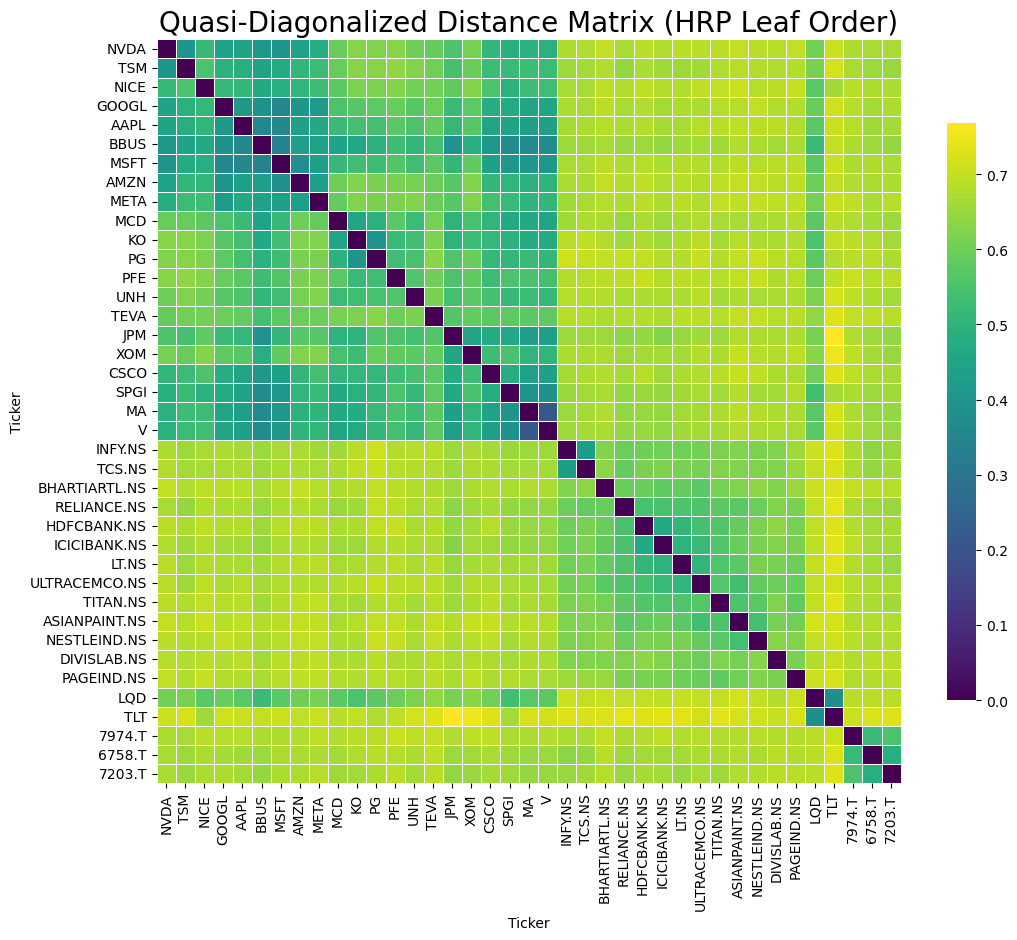

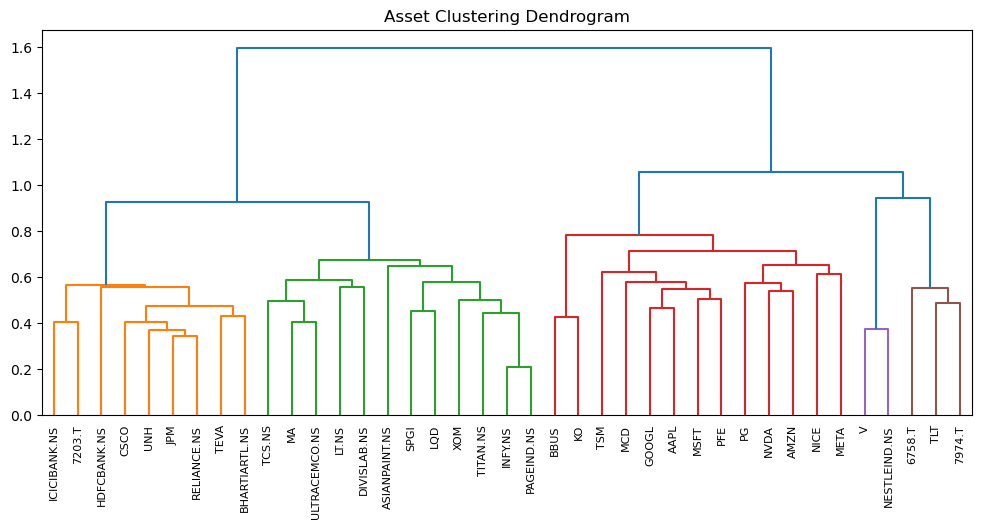

In [18]:
# Static HRP
returns_inr = prices_inr.pct_change().dropna()
returns_std = returns_inr / returns_inr.std()

# Compute correlation and distance matrices
correlation = returns_std.corr()
distance = np.sqrt(0.5 * (1 - correlation))

condensed_distance = squareform(distance)
link = sch.linkage(condensed_distance, method='ward')
leaf_order = sch.leaves_list(link)
sorted_assets = returns_inr.columns[leaf_order].tolist()

# Heatmap of distance matrix
plt.figure(figsize=(12, 10))
sns.heatmap(distance, cmap='viridis', square=True, linewidths=0.5, cbar_kws={"shrink": 0.75},
            xticklabels=True, yticklabels=True)
plt.title('Original Distance Matrix', fontsize=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

# Heatmap of quasi-diagonalized distance matrix
distance_reordered = distance.iloc[leaf_order, leaf_order]

plt.figure(figsize=(12, 10))
sns.heatmap(distance_reordered, cmap='viridis', square=True, linewidths=0.5, cbar_kws={"shrink": 0.75},
            xticklabels=distance.columns[leaf_order], yticklabels=distance.columns[leaf_order])
plt.title('Quasi-Diagonalized Distance Matrix (HRP Leaf Order)', fontsize=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

# Plot dendrogram
plt.figure(figsize=(12, 5))
sch.dendrogram(link, labels=returns_std.columns[leaf_order], leaf_rotation=90, color_threshold=0.5 * np.max(link[:, 2]))
plt.title('Asset Clustering Dendrogram')
plt.show()

In [22]:
# ── Core HRP Functions ────────────────────────────────────────────────────
def get_quasi_diag(link):
    """Reconstruct quasi-diagonal asset order from linkage matrix."""
    link      = link.astype(int)
    sort_ix   = pd.Series([link[-1, 0], link[-1, 1]])
    num_items = link[-1, 3]

    while sort_ix.max() >= num_items:
        sort_ix.index = range(0, sort_ix.shape[0] * 2, 2)
        df            = sort_ix[sort_ix >= num_items]
        i             = df.index
        j             = df.values - num_items
        sort_ix[i]    = link[j, 0]
        df            = pd.Series(link[j, 1], index=i + 1)
        sort_ix       = pd.concat([sort_ix, df]).sort_index()
        sort_ix.index = range(sort_ix.shape[0])

    return sort_ix.tolist()


def get_cluster_var(cov, cluster_items):
    """Compute variance of inverse-vol weighted cluster portfolio."""
    cov_slice = cov.loc[cluster_items, cluster_items]
    vols      = np.sqrt(np.diag(cov_slice.values))
    ivp       = (1 / vols) / (1 / vols).sum()
    return float(ivp @ cov_slice.values @ ivp)


def hrp_weights(cov, sort_ix):
    """
    Recursive bisection: allocate weights via inverse cluster variance.
    Returns a pd.Series of weights indexed by asset name.
    """
    w         = pd.Series(1.0, index=sort_ix)
    clusters  = [sort_ix]

    while clusters:
        clusters = [c[s:e]
                    for c in clusters
                    for s, e in ((0, len(c) // 2), (len(c) // 2, len(c)))
                    if len(c) > 1]

        for i in range(0, len(clusters), 2):
            left  = clusters[i]
            right = clusters[i + 1]

            var_l = get_cluster_var(cov, left)
            var_r = get_cluster_var(cov, right)
            alpha = 1 - var_l / (var_l + var_r)   # weight to left cluster

            w[left]  *= alpha
            w[right] *= 1 - alpha

    return w


# ── Risk Measure Dispatcher ───────────────────────────────────────────────
def compute_risk(returns, weights, rm, rf=0, alpha=0.05):
    """
    Compute portfolio risk for a given risk measure.
    returns : pd.DataFrame  (T x N)
    weights : pd.Series     (N,)  aligned to returns.columns
    """
    r   = returns.values @ weights.values          # portfolio return series
    T   = len(r)
    mu  = r.mean()
    vol = r.std(ddof=1)

    # Drawdown series
    cum     = np.cumprod(1 + r)
    running = np.maximum.accumulate(cum)
    dd      = (running - cum) / running            # relative drawdown

    if rm == 'vol':
        return vol

    elif rm == 'MV':                               # Mean-Variance (variance)
        return vol ** 2

    elif rm == 'MAD':                              # Mean Absolute Deviation
        return np.mean(np.abs(r - mu))

    elif rm == 'MSV':                              # Semi-Variance (downside vol)
        neg = r[r < mu] - mu
        return np.sqrt(np.mean(neg ** 2))

    elif rm == 'FLPM':                             # First Lower Partial Moment
        return np.mean(np.maximum(rf - r, 0))

    elif rm == 'SLPM':                             # Second Lower Partial Moment
        return np.sqrt(np.mean(np.maximum(rf - r, 0) ** 2))

    elif rm == 'VaR':                              # Value at Risk
        return -np.percentile(r, alpha * 100)

    elif rm == 'CVaR':                             # Conditional VaR (ES)
        var = -np.percentile(r, alpha * 100)
        return -r[r <= -var].mean()

    elif rm == 'EVaR':                             # Entropic VaR (Chernoff bound)
        best = np.inf
        for z in np.linspace(0.01, 5, 200):
            candidate = (np.log(np.mean(np.exp(-z * r))) + np.log(1 / alpha)) / z
            best      = min(best, candidate)
        return best

    elif rm == 'WR':                               # Worst Realisation
        return -r.min()

    elif rm == 'MDD':                              # Max Drawdown (absolute)
        cum_abs = np.cumprod(1 + r)
        run_abs = np.maximum.accumulate(cum_abs)
        return float(np.max(run_abs - cum_abs))

    elif rm == 'ADD':                              # Average Drawdown (absolute)
        cum_abs = np.cumprod(1 + r)
        run_abs = np.maximum.accumulate(cum_abs)
        return float(np.mean(run_abs - cum_abs))

    elif rm == 'DaR':                              # Drawdown at Risk (relative)
        return float(np.percentile(dd, (1 - alpha) * 100))

    elif rm == 'CDaR':                             # Conditional DaR (relative)
        dar = np.percentile(dd, (1 - alpha) * 100)
        return float(dd[dd >= dar].mean())

    elif rm == 'EDaR':                             # Entropic DaR
        best = np.inf
        for z in np.linspace(0.01, 5, 200):
            candidate = (np.log(np.mean(np.exp(z * dd))) + np.log(1 / alpha)) / z
            best      = min(best, candidate)
        return best

    elif rm == 'UCI':                              # Ulcer Index (relative)
        return float(np.sqrt(np.mean(dd ** 2)))

    elif rm == 'MDD_Rel':                          # Max Drawdown relative
        return float(dd.max())

    elif rm == 'ADD_Rel':                          # Average Drawdown relative
        return float(dd.mean())

    elif rm == 'DaR_Rel':                          # DaR relative (same as DaR here)
        return float(np.percentile(dd, (1 - alpha) * 100))

    elif rm == 'CDaR_Rel':                         # CDaR relative
        dar = np.percentile(dd, (1 - alpha) * 100)
        return float(dd[dd >= dar].mean())

    elif rm == 'EDaR_Rel':                         # Entropic DaR relative
        best = np.inf
        for z in np.linspace(0.01, 5, 200):
            candidate = (np.log(np.mean(np.exp(z * dd))) + np.log(1 / alpha)) / z
            best      = min(best, candidate)
        return best

    elif rm == 'UCI_Rel':                          # UCI relative (same as UCI)
        return float(np.sqrt(np.mean(dd ** 2)))

    else:
        raise ValueError(f"Unknown risk measure: {rm}")


def hrp_risk_parity(returns, cov, sort_ix, rm, rf=0, alpha=0.05,
                    tol=1e-8, max_iter=100):

    # Step 1: baseline HRP weights (always positive, sums to 1)
    w = hrp_weights(cov, sort_ix)

    if rm in ('vol', 'MV'):
        return w.reindex(returns.columns)

    # Step 2: build ALL bisection levels, not just the top split
    # ── FIX: recursive cluster tree, not a single mid-split ──────────────
    def recursive_bisect(items):
        """Return list of (left, right) pairs at every level of the tree."""
        pairs = []
        if len(items) < 2:
            return pairs
        mid = len(items) // 2
        left, right = items[:mid], items[mid:]
        pairs.append((left, right))
        pairs.extend(recursive_bisect(left))
        pairs.extend(recursive_bisect(right))
        return pairs

    all_pairs = recursive_bisect(sort_ix)

    for iteration in range(max_iter):
        w_old = w.copy()

        for left, right in all_pairs:
            w_left_sum  = w[left].sum()
            w_right_sum = w[right].sum()

            if w_left_sum < 1e-12 or w_right_sum < 1e-12:
                continue

            # Normalise within-cluster weights before computing risk
            w_l = w[left]  / w_left_sum
            w_r = w[right] / w_right_sum

            risk_l = compute_risk(returns[left],  w_l, rm, rf, alpha)
            risk_r = compute_risk(returns[right], w_r, rm, rf, alpha)

            total = risk_l + risk_r
            if total < 1e-12:
                continue

            # ── FIX: clip alpha to avoid zeroing out clusters ─────────────
            alpha_l = np.clip(1 - risk_l / total, 0.05, 0.95)

            w[left]  = w[left]  * (alpha_l       / w_left_sum  * (w_left_sum + w_right_sum))
            w[right] = w[right] * ((1 - alpha_l) / w_right_sum * (w_left_sum + w_right_sum))

        # Renormalise globally
        w = w / w.sum()

        if np.max(np.abs(w - w_old)) < tol:
            print(f"  {rm}: converged at iteration {iteration+1}")
            break

    # ── FIX: floor weights to avoid zeros ────────────────────────────────
    floor = 0.001   # 0.1% minimum per asset
    w = w.clip(lower=floor)
    w = w / w.sum()

    return w.reindex(returns.columns)


# ── Run All Risk Measures ─────────────────────────────────────────────────
rms = ['vol', 'MV', 'MAD', 'MSV', 'FLPM', 'SLPM', 'VaR', 'CVaR', 'EVaR', 'WR',
       'MDD', 'ADD', 'DaR', 'CDaR', 'EDaR', 'UCI',
       'MDD_Rel', 'ADD_Rel', 'DaR_Rel', 'CDaR_Rel', 'EDaR_Rel', 'UCI_Rel']

cov      = returns_inr.cov()
sort_ix  = [returns_inr.columns[i] for i in get_quasi_diag(link)]

w_s = pd.DataFrame()

for rm in rms:
    try:
        w = hrp_risk_parity(returns_inr, cov, sort_ix, rm, rf=0, alpha=0.05)
        w_s = pd.concat([w_s, w.rename(rm)], axis=1)
        print(f"{rm:12s}  sum={w.sum():.6f}  min={w.min():.4f}  max={w.max():.4f}")
    except Exception as e:
        print(f"{rm}: {e}")

# ── Sanity checks ─────────────────────────────────────────────────────────
print(f"\n{'='*50}")
print(f"Weight matrix shape : {w_s.shape}")
print(f"Column sums (all ~1):\n{w_s.sum().round(6)}")

# ── Display ───────────────────────────────────────────────────────────────
w_s.style.format("{:.2%}").background_gradient(cmap='YlGn')

vol           sum=1.000000  min=0.0031  max=0.1822
MV            sum=1.000000  min=0.0031  max=0.1822
  MAD: converged at iteration 6
MAD           sum=1.000000  min=0.0078  max=0.0856
  MSV: converged at iteration 7
MSV           sum=1.000000  min=0.0075  max=0.0912
  FLPM: converged at iteration 6
FLPM          sum=1.000000  min=0.0077  max=0.0849
  SLPM: converged at iteration 7
SLPM          sum=1.000000  min=0.0073  max=0.0936
  VaR: converged at iteration 7
VaR           sum=1.000000  min=0.0067  max=0.0862
  CVaR: converged at iteration 7
CVaR          sum=1.000000  min=0.0070  max=0.0970
  EVaR: converged at iteration 3
EVaR          sum=1.000000  min=0.0156  max=0.0313
  WR: converged at iteration 7
WR            sum=1.000000  min=0.0058  max=0.1163
  MDD: converged at iteration 7
MDD           sum=1.000000  min=0.0017  max=0.1289
  ADD: converged at iteration 7
ADD           sum=1.000000  min=0.0030  max=0.0922
  DaR: converged at iteration 7
DaR           sum=1.000000  min=0

,vol,MV,MAD,MSV,FLPM,SLPM,VaR,CVaR,EVaR,WR,MDD,ADD,DaR,CDaR,EDaR,UCI,MDD_Rel,ADD_Rel,DaR_Rel,CDaR_Rel,EDaR_Rel,UCI_Rel
ASIANPAINT.NS,4.21%,4.21%,3.78%,3.83%,3.76%,3.83%,3.59%,3.83%,3.12%,2.78%,2.18%,1.55%,2.19%,2.81%,3.02%,2.35%,3.77%,2.13%,2.19%,2.81%,3.02%,2.35%
BHARTIARTL.NS,2.21%,2.21%,1.93%,1.97%,2.01%,1.97%,2.15%,1.99%,1.56%,2.26%,2.70%,3.37%,1.43%,1.53%,1.60%,1.78%,1.22%,2.08%,1.43%,1.53%,1.60%,1.78%
DIVISLAB.NS,2.51%,2.51%,2.03%,2.11%,2.16%,2.21%,1.97%,2.24%,1.56%,2.03%,1.16%,1.17%,2.34%,2.33%,1.70%,2.33%,2.29%,2.26%,2.34%,2.33%,1.70%,2.33%
HDFCBANK.NS,2.96%,2.96%,3.50%,3.16%,3.46%,3.12%,3.35%,3.08%,3.12%,2.65%,3.28%,3.50%,3.89%,2.72%,3.19%,3.13%,1.97%,3.20%,3.89%,2.72%,3.19%,3.13%
ICICIBANK.NS,1.80%,1.80%,2.74%,2.44%,2.79%,2.41%,2.81%,2.38%,3.12%,1.87%,2.29%,2.33%,1.90%,1.75%,3.06%,2.22%,1.77%,2.67%,1.90%,1.75%,3.06%,2.22%
INFY.NS,3.21%,3.21%,3.39%,3.09%,3.46%,3.16%,3.55%,3.18%,3.13%,2.93%,1.48%,1.51%,2.02%,2.30%,3.01%,2.22%,2.26%,2.42%,2.02%,2.30%,3.01%,2.22%
LT.NS,1.49%,1.49%,1.72%,1.54%,1.75%,1.52%,1.83%,1.53%,1.56%,1.03%,1.60%,1.37%,0.90%,0.83%,1.50%,1.05%,0.78%,1.24%,0.90%,0.83%,1.50%,1.05%
NESTLEIND.NS,5.37%,5.37%,4.23%,4.69%,4.37%,4.78%,4.09%,4.81%,3.13%,5.14%,4.33%,3.52%,4.53%,5.32%,3.31%,4.95%,5.73%,4.57%,4.53%,5.32%,3.31%,4.95%
PAGEIND.NS,2.25%,2.25%,1.88%,2.08%,1.90%,2.10%,1.85%,2.17%,1.56%,2.32%,3.36%,1.87%,1.84%,2.00%,1.52%,1.66%,2.09%,1.37%,1.84%,2.00%,1.52%,1.66%
RELIANCE.NS,2.21%,2.21%,2.97%,2.82%,2.99%,2.81%,3.08%,2.86%,3.12%,2.54%,1.79%,1.86%,3.71%,2.86%,3.14%,2.89%,1.80%,2.80%,3.71%,2.86%,3.14%,2.89%


All required risk measures present

Sum of blended weights : 1.000000

Blended weights (descending):
LQD              12.46%
TLT               6.10%
NESTLEIND.NS      4.99%
PG                4.23%
ASIANPAINT.NS     3.56%
7974.T            3.54%
KO                3.37%
MCD               3.27%
TITAN.NS          3.16%
HDFCBANK.NS       3.03%
BBUS              2.84%
INFY.NS           2.79%
V                 2.76%
TCS.NS            2.61%
RELIANCE.NS       2.46%
7203.T            2.41%
MA                2.39%
PAGEIND.NS        2.33%
XOM               2.17%
DIVISLAB.NS       2.17%
JPM               2.15%
BHARTIARTL.NS     2.10%
ICICIBANK.NS      2.08%
6758.T            1.86%
GOOGL             1.71%
CSCO              1.60%
MSFT              1.55%
NICE              1.53%
ULTRACEMCO.NS     1.51%
PFE               1.46%
SPGI              1.42%
LT.NS             1.42%
AAPL              1.38%
TEVA              1.29%
UNH               1.24%
TSM               1.19%
NVDA              0.73%
AMZN       

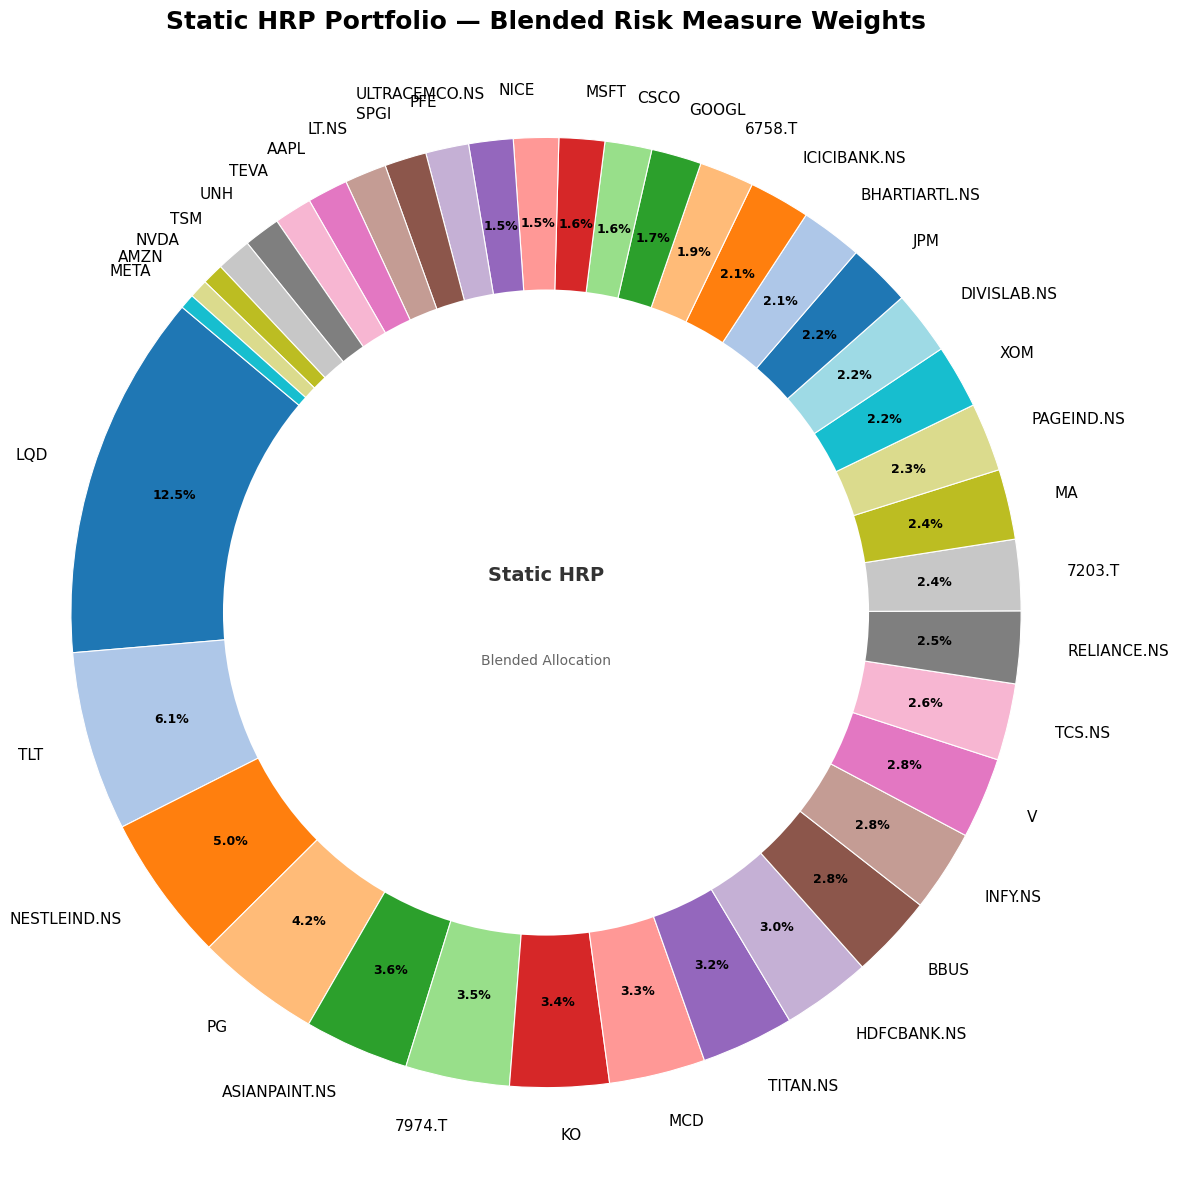

,Blended Weight,Weight (%)
LQD,0.1246,12.46%
TLT,0.0610,6.10%
NESTLEIND.NS,0.0499,4.99%
PG,0.0423,4.23%
ASIANPAINT.NS,0.0356,3.56%
7974.T,0.0354,3.54%
KO,0.0337,3.37%
MCD,0.0327,3.27%
TITAN.NS,0.0316,3.16%
HDFCBANK.NS,0.0303,3.03%


In [23]:
# ── Blended HRP Weights ───────────────────────────────────────────────────
rms_blend = ['vol', 'MV', 'MSV', 'SLPM', 'CVaR', 'MDD', 'CDaR']

weighting_scheme = {
    'vol'  : 0.175,
    'MV'   : 0.175,
    'MSV'  : 0.125,
    'SLPM' : 0.125,
    'CVaR' : 0.10,
    'MDD'  : 0.15,
    'CDaR' : 0.15,
}

# Validate all required rms were computed successfully
missing = [rm for rm in rms_blend if rm not in w_s.columns]
if missing:
    print(f"Missing risk measures in w_s: {missing}")
else:
    print("All required risk measures present")

# ── Blend ─────────────────────────────────────────────────────────────────
final_weights = pd.Series(0.0, index=w_s.index)
for rm, wt in weighting_scheme.items():
    final_weights += w_s[rm] * wt

final_weights /= final_weights.sum()    # renormalise → exactly 1.0

print(f"\nSum of blended weights : {final_weights.sum():.6f}")
print(f"\nBlended weights (descending):")
print(final_weights.sort_values(ascending=False).map("{:.2%}".format).to_string())

# ── Donut Chart ───────────────────────────────────────────────────────────
final_weights_sorted = final_weights.sort_values(ascending=False)

colors = plt.cm.tab20.colors[:len(final_weights_sorted)]

fig, ax = plt.subplots(figsize=(12, 12))

wedges, texts, autotexts = ax.pie(
    final_weights_sorted,
    labels=final_weights_sorted.index,
    autopct=lambda p: f'{p:.1f}%' if p > 1.5 else '',
    startangle=140,
    pctdistance=0.82,
    colors=colors,
    wedgeprops=dict(linewidth=0.8, edgecolor='white'),
    textprops={'fontsize': 11}
)

for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight('bold')

# Donut hole
ax.add_artist(plt.Circle((0, 0), 0.68, fc='white'))

# Centre text
ax.text(0,  0.08, 'Static HRP',        ha='center', va='center',
        fontsize=14, fontweight='bold', color='#333333')
ax.text(0, -0.10, 'Blended Allocation', ha='center', va='center',
        fontsize=10, color='#666666')

ax.set_title('Static HRP Portfolio — Blended Risk Measure Weights',
             fontsize=18, pad=20, fontweight='bold')
ax.axis('equal')
plt.tight_layout()
plt.show()

# ── Weight table ──────────────────────────────────────────────────────────
final_weights_df = pd.DataFrame({
    'Blended Weight' : final_weights,
    'Weight (%)' : final_weights * 100
}).sort_values('Blended Weight', ascending=False)

final_weights_df.style \
    .format({'Blended Weight': '{:.4f}', 'Weight (%)': '{:.2f}%'}) \
    .background_gradient(cmap='YlGn', subset=['Blended Weight'])

In [25]:
# ── Dynamic HRP ───────────────────────────────────────────────────────────
transaction_cost = 0.003
rolling_window   = 126    
vol_threshold    = 0.05
rf               = 0
alpha            = 0.05

rms_blend = ['vol', 'MV', 'MSV', 'SLPM', 'CVaR', 'MDD', 'CDaR']
weighting_scheme = {
    'vol'  : 0.175,
    'MV'   : 0.175,
    'MSV'  : 0.125,
    'SLPM' : 0.125,
    'CVaR' : 0.10,
    'MDD'  : 0.15,
    'CDaR' : 0.15,
}

dates          = returns_inr.index
portfolio_tc   = [1_000_000]
portfolio_no_tc= [1_000_000]
weights_over_time = []
rebalance_dates   = []

# ── compute blended HRP weights for a return window ───────────────
def compute_blended_weights(window_returns, rms_blend, weighting_scheme,
                             rf=0, alpha=0.05):
    """
    Runs manual HRP for each rm on the given window,
    returns a blended pd.Series summing to 1.
    """
    # Correlation + distance
    corr = window_returns.corr()
    corr = (corr + corr.T) / 2
    corr = corr.clip(-1, 1)
    np.fill_diagonal(corr.values, 1.0)

    dist = np.sqrt(0.5 * (1 - corr))
    dist = (dist + dist.T) / 2
    np.fill_diagonal(dist.values, 0.0)

    cond     = squareform(dist.values)
    lnk      = sch.linkage(cond, method='ward')
    sort_ix  = [window_returns.columns[i] for i in get_quasi_diag(lnk)]
    cov      = window_returns.cov()

    w_s = pd.DataFrame()
    for rm in rms_blend:
        try:
            w = hrp_risk_parity(window_returns, cov, sort_ix,
                                rm=rm, rf=rf, alpha=alpha)
            if w is not None and not w.isnull().any():
                w_s = pd.concat([w_s, w.rename(rm)], axis=1)
        except Exception as e:
            print(f"  ⚠️  rm={rm} failed: {e}")

    if w_s.empty:
        return None

    blended = pd.Series(0.0, index=w_s.index)
    total_wt = 0.0
    for rm, wt in weighting_scheme.items():
        if rm in w_s.columns:
            blended  += w_s[rm] * wt
            total_wt += wt

    blended /= total_wt         
    blended /= blended.sum()    
    return blended

# ── Initial allocation (first window) ────────────────────────────────────
window_returns  = returns_inr.iloc[:rolling_window]
current_weights = compute_blended_weights(window_returns, rms_blend,
                                          weighting_scheme, rf, alpha)

if current_weights is None:
    raise RuntimeError("Initial window HRP failed — check your data.")

print(f"Initial weights computed. Assets: {len(current_weights)}")
print(f"   Sum: {current_weights.sum():.6f}")

# ── Rolling loop ──────────────────────────────────────────────────────────
for i in range(rolling_window, len(dates)):

    # ── Volatility regime check ───────────────────────────────────────────
    past_vol = returns_inr.iloc[i - rolling_window : i].std().mean()
    prev_vol = returns_inr.iloc[i - rolling_window - 1 : i - 1].std().mean()

    
    if prev_vol < 1e-10:
        vol_change = 0.0
    else:
        vol_change = abs((past_vol - prev_vol) / prev_vol)

    rebalanced = False

    if vol_change > vol_threshold:
        window_returns  = returns_inr.iloc[i - rolling_window : i]
        new_weights     = compute_blended_weights(window_returns, rms_blend,
                                                  weighting_scheme, rf, alpha)

        if new_weights is not None:
            turnover   = (new_weights - current_weights).abs().sum() / 2
            cost       = turnover * transaction_cost

            current_weights = new_weights.copy()
            rebalanced      = True
            rebalance_dates.append(dates[i])

    # ── Apply today's return BEFORE deducting cost ────────────────────────
    aligned_weights = current_weights.reindex(returns_inr.columns).fillna(0)
    aligned_weights /= aligned_weights.sum()

    today_return    = float(returns_inr.iloc[i] @ aligned_weights)

    new_value_tc    = portfolio_tc[-1]    * (1 + today_return)
    new_value_no_tc = portfolio_no_tc[-1] * (1 + today_return)

    if rebalanced:
        new_value_tc -= new_value_tc * cost

    portfolio_tc.append(new_value_tc)
    portfolio_no_tc.append(new_value_no_tc)
    weights_over_time.append(aligned_weights)

# ── Assemble results ──────────────────────────────────────────────────────
weights_df = pd.DataFrame(
    weights_over_time,
    index=dates[rolling_window:]       
)

portfolio_tc_s    = pd.Series(portfolio_tc,    index=dates[rolling_window - 1:])
portfolio_no_tc_s = pd.Series(portfolio_no_tc, index=dates[rolling_window - 1:])

print(f"\nSimulation complete")
print(f"   Trading days     : {len(dates) - rolling_window}")
print(f"   Rebalances       : {len(rebalance_dates)}")
print(f"   Final value (TC) : ₹{portfolio_tc[-1]:,.0f}")
print(f"   Final value (NTC): ₹{portfolio_no_tc[-1]:,.0f}")
print(f"   Total cost drag  : ₹{portfolio_no_tc[-1] - portfolio_tc[-1]:,.0f}")

  MSV: converged at iteration 7
  SLPM: converged at iteration 7
  CVaR: converged at iteration 7
  MDD: converged at iteration 7
  CDaR: converged at iteration 7
Initial weights computed. Assets: 39
   Sum: 1.000000
  MSV: converged at iteration 7
  SLPM: converged at iteration 7
  CVaR: converged at iteration 6
  MDD: converged at iteration 7
  CDaR: converged at iteration 7
  MSV: converged at iteration 7
  SLPM: converged at iteration 7
  CVaR: converged at iteration 6
  MDD: converged at iteration 7
  CDaR: converged at iteration 7
  MSV: converged at iteration 7
  SLPM: converged at iteration 7
  CVaR: converged at iteration 7
  MDD: converged at iteration 7
  CDaR: converged at iteration 7
  MSV: converged at iteration 7
  SLPM: converged at iteration 7
  CVaR: converged at iteration 7
  MDD: converged at iteration 7
  CDaR: converged at iteration 7
  MSV: converged at iteration 7
  SLPM: converged at iteration 7
  CVaR: converged at iteration 7
  MDD: converged at iteration 7
 

[*********************100%***********************]  1 of 1 completed


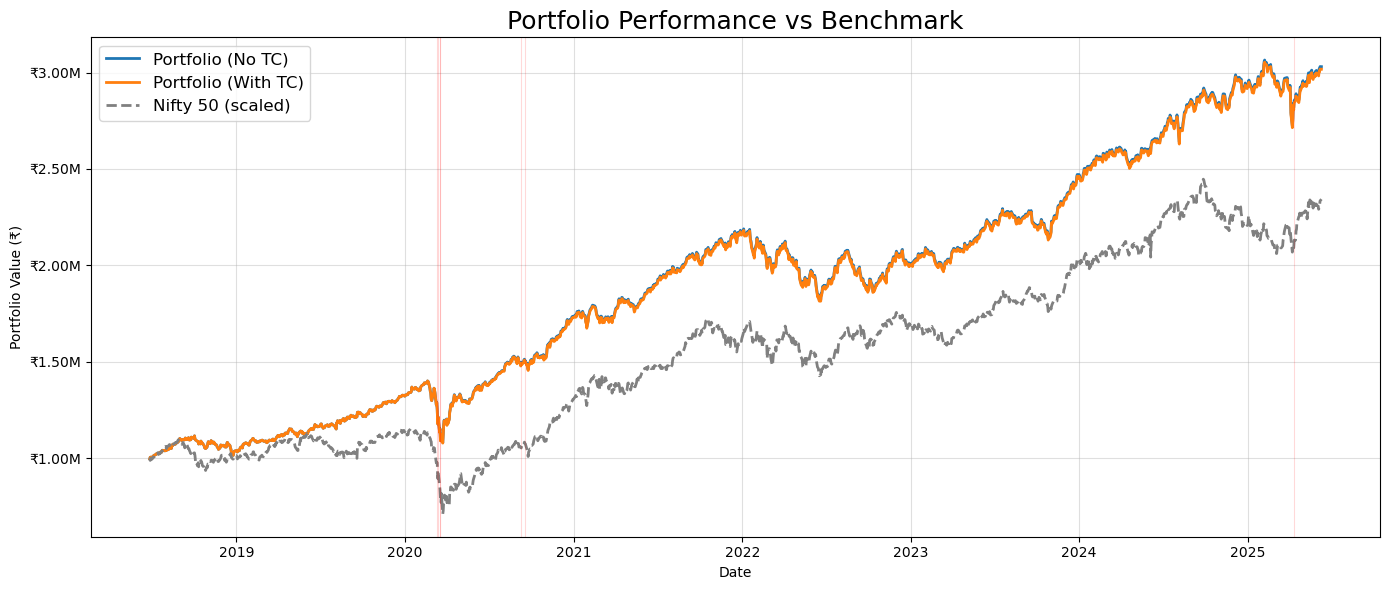

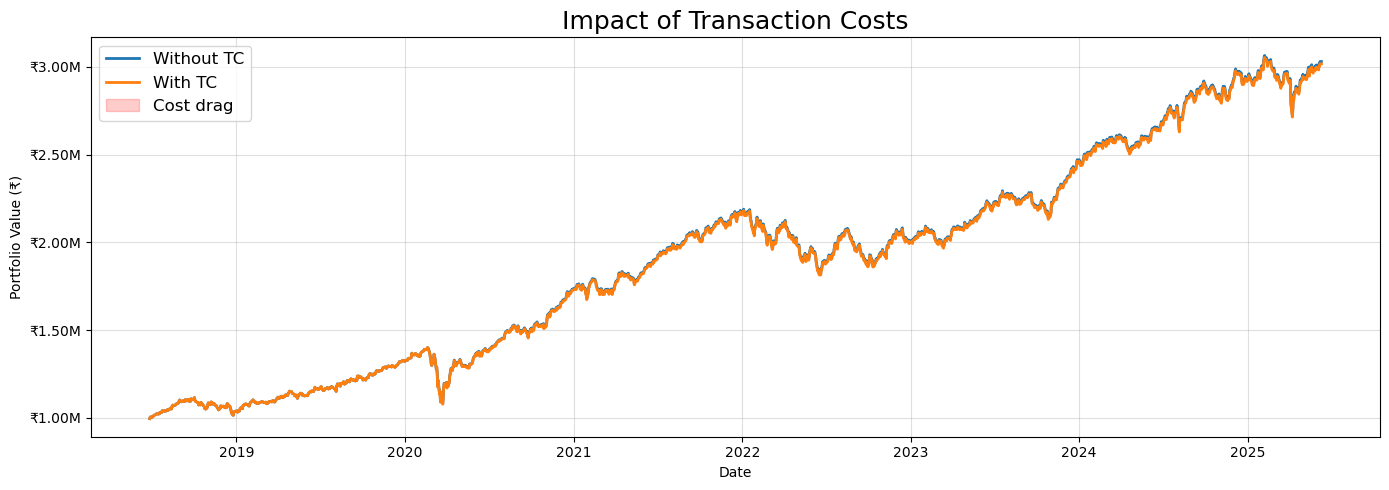

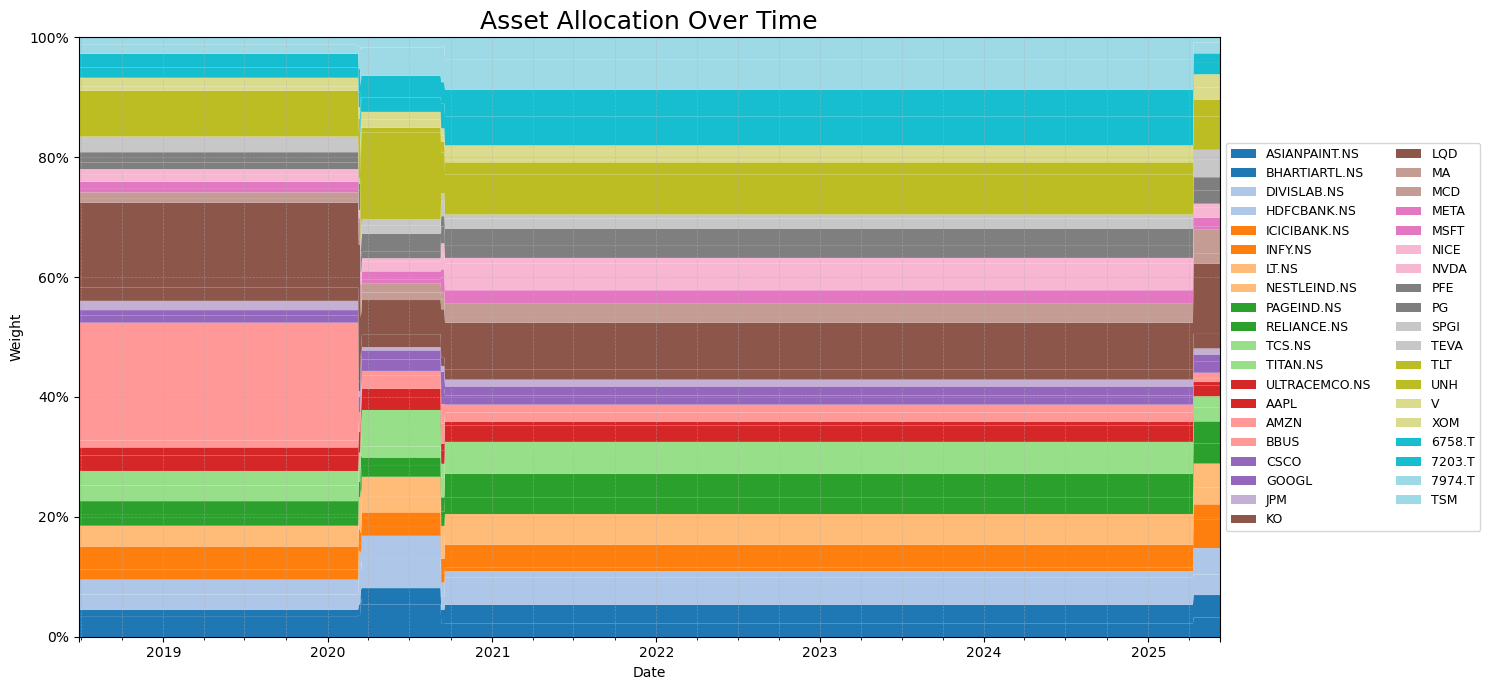

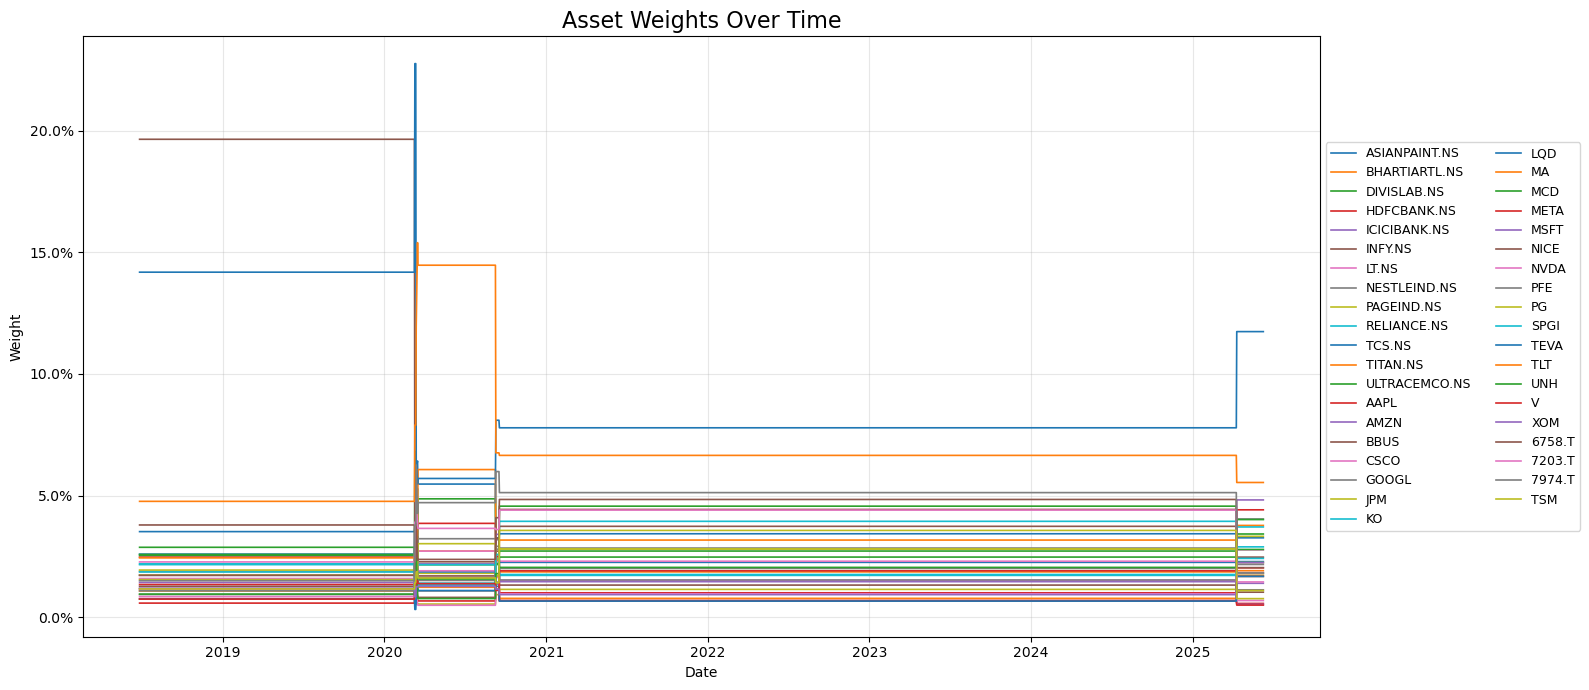

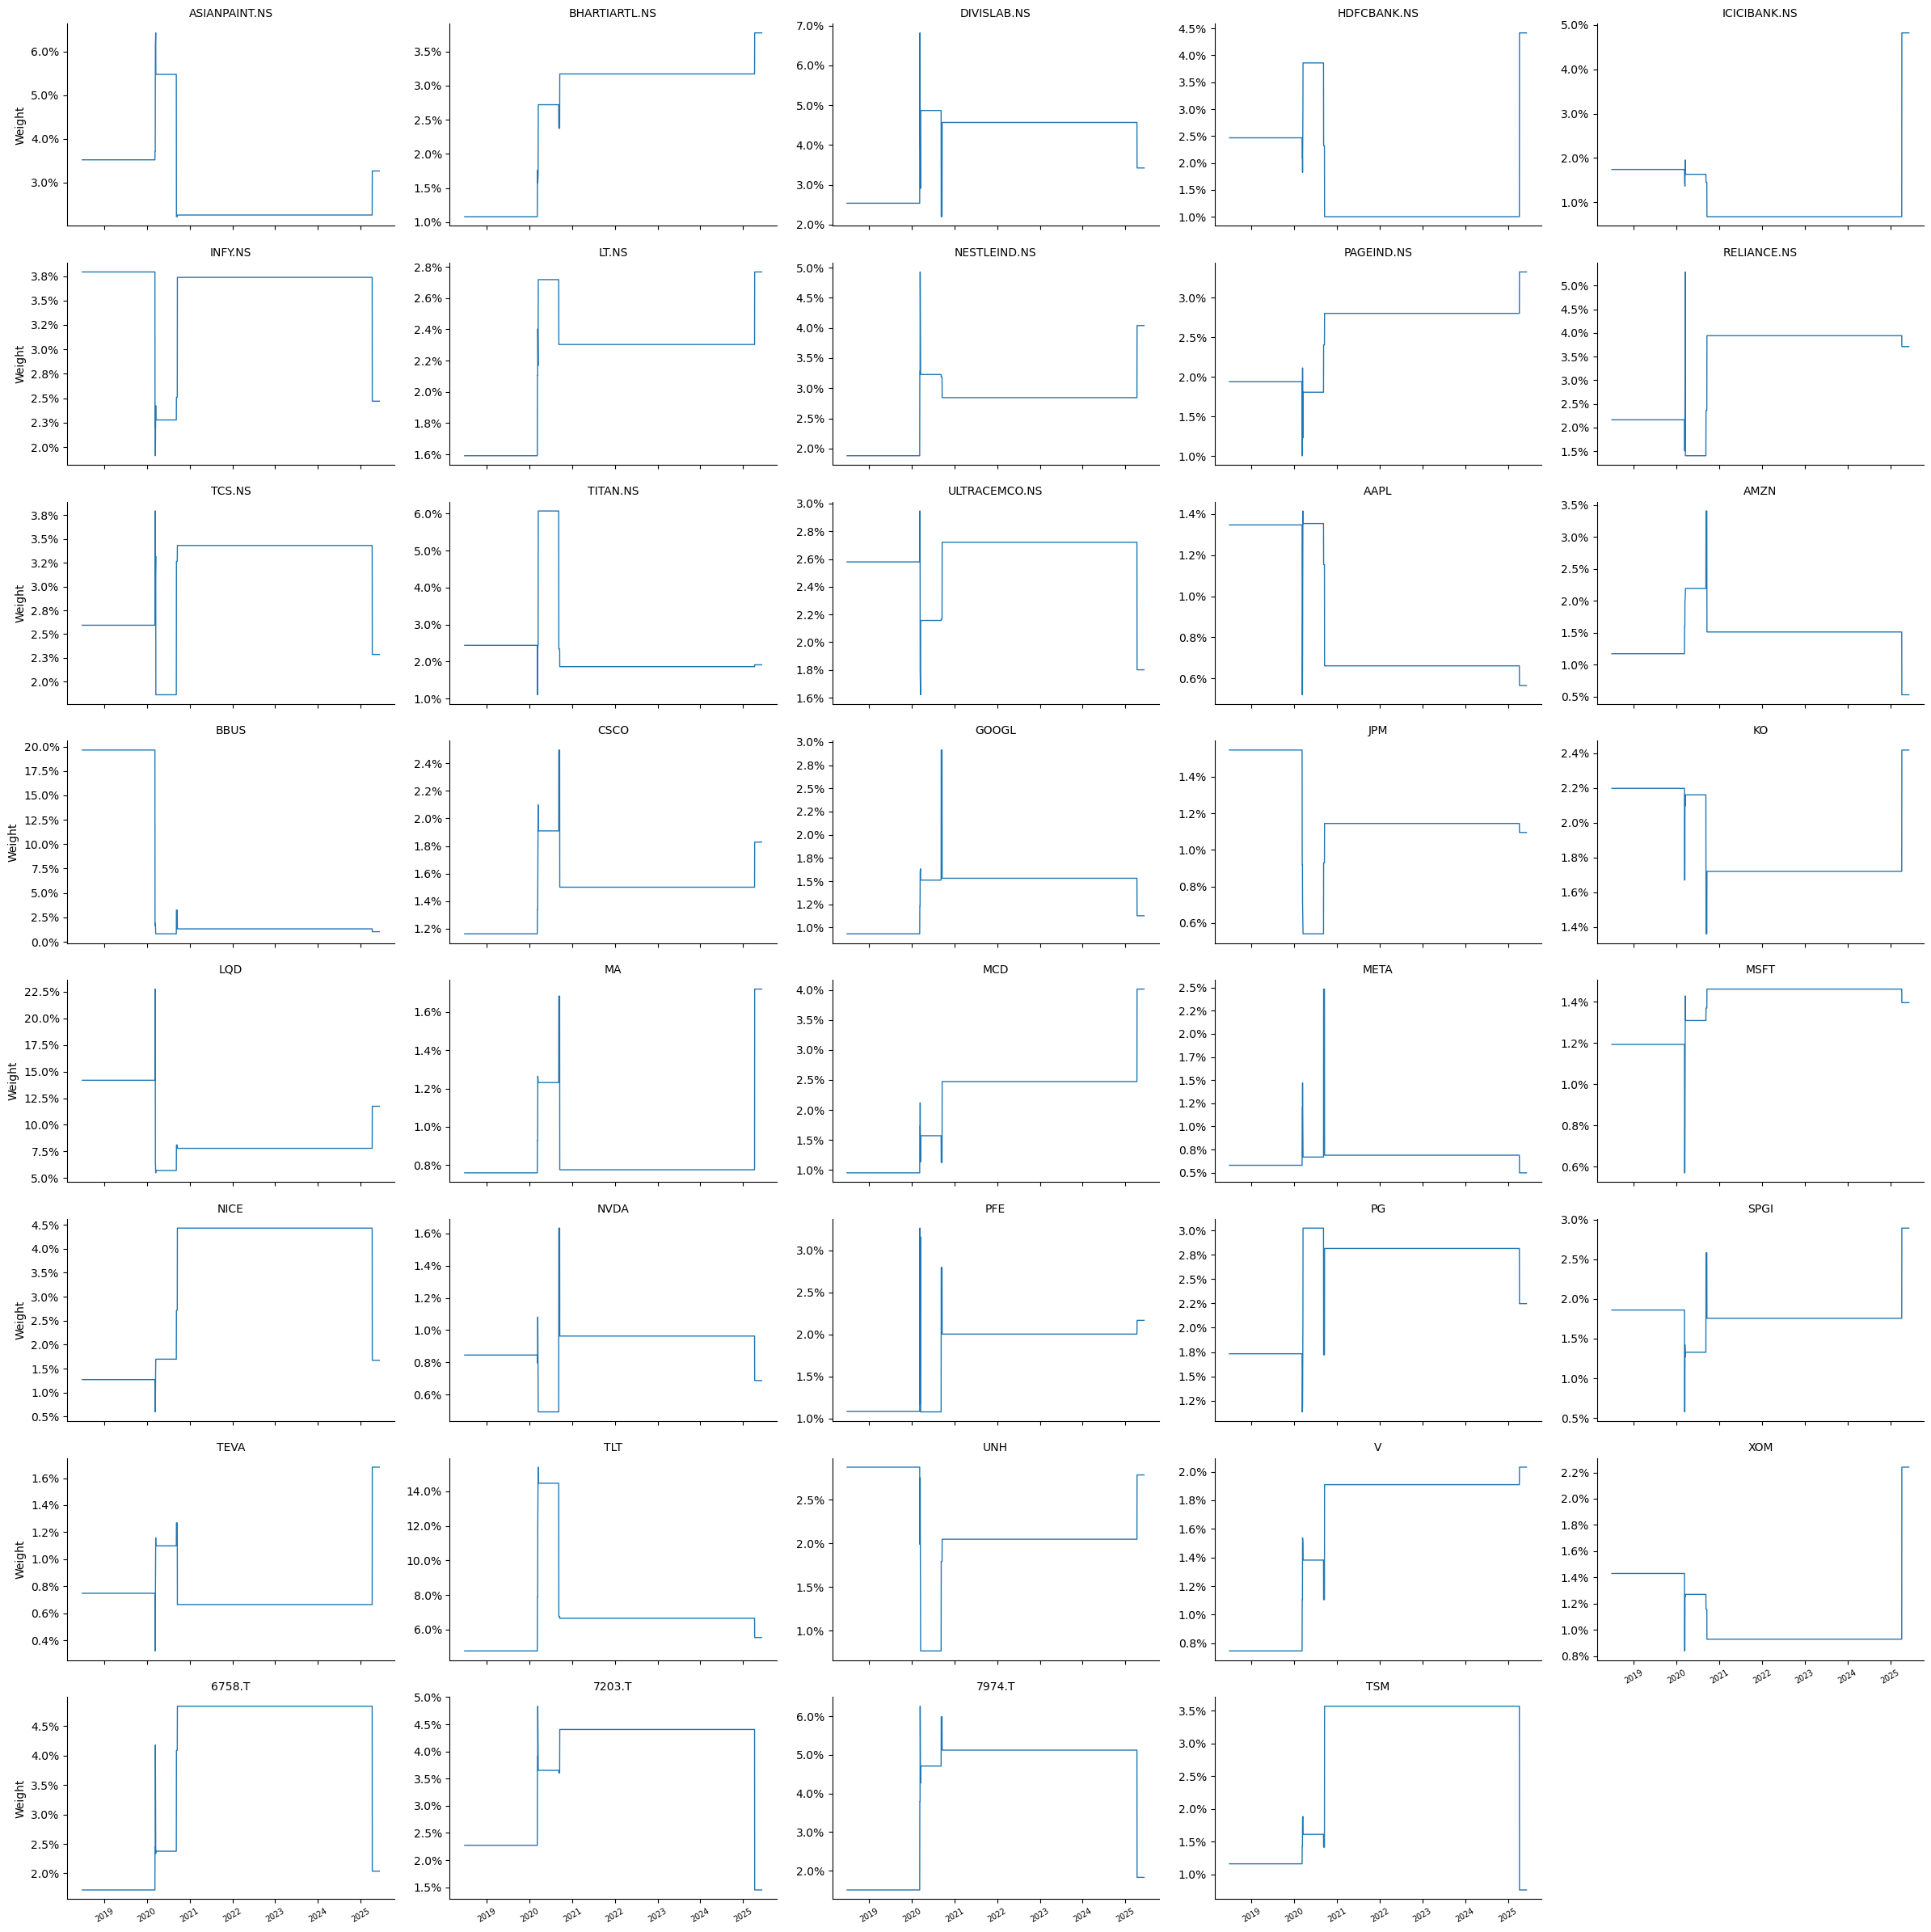

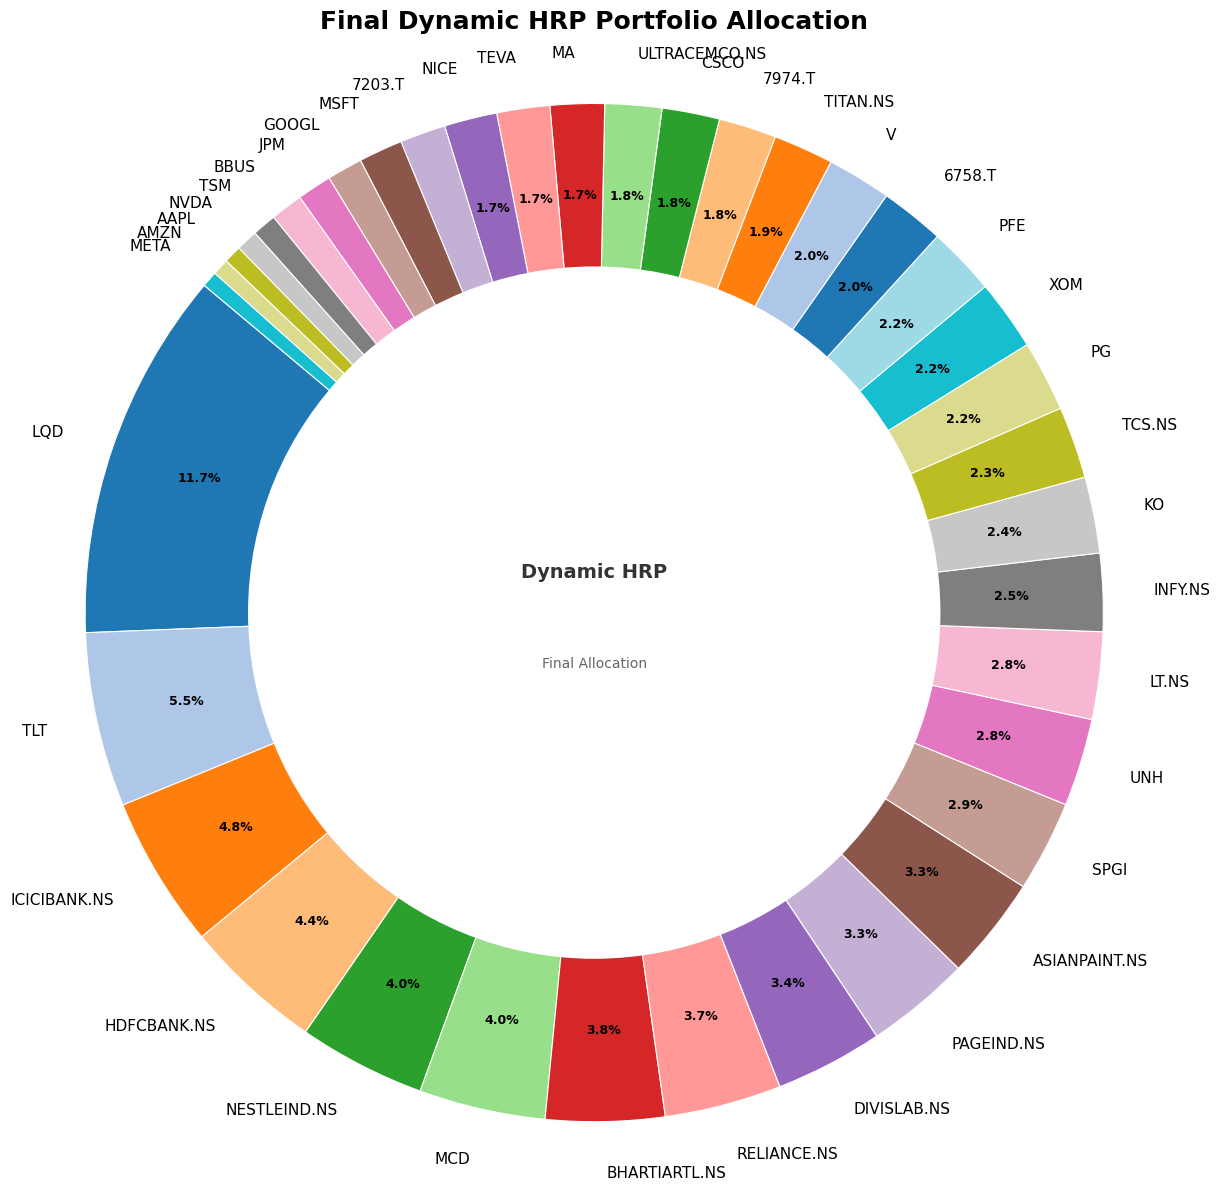


                              PERFORMANCE SUMMARY                               
Portfolio (With TC)             Total=202.9%  Ann=16.6%  Vol=11.6%  SR=1.43  MDD=-23.0%
Portfolio (No TC)               Total=204.2%  Ann=16.7%  Vol=11.6%  SR=1.44  MDD=-22.8%
Nifty 50                        Total=135.2%  Ann=12.6%  Vol=17.4%  SR=0.73  MDD=-38.4%
Total rebalances : 7
Avg rebal freq   : every 259 days


In [28]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

plot_dates = dates[rolling_window:]     

assert len(plot_dates) == len(portfolio_tc[1:]), \
    f"Length mismatch: dates={len(plot_dates)}, portfolio={len(portfolio_tc[1:])}"

# ── Benchmark alignment ───────────────────────────────────────────────────
benchmark_data = yf.download('^NSEI', start=start_date, end=end_date)['Close']
benchmark_data = align(benchmark_data)
benchmark_aligned = benchmark_data.reindex(plot_dates).ffill().bfill()
benchmark_scaled  = benchmark_aligned / benchmark_aligned.iloc[0] * portfolio_tc[1]

# ── 1. Portfolio Performance vs Benchmark ────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(plot_dates, portfolio_no_tc[1:], label='Portfolio (No TC)',   linewidth=2)
ax.plot(plot_dates, portfolio_tc[1:],    label='Portfolio (With TC)', linewidth=2)
ax.plot(plot_dates, benchmark_scaled,    label='Nifty 50 (scaled)',
        linewidth=2, linestyle='--', color='gray')

# Mark rebalance dates
for rd in rebalance_dates:
    ax.axvline(rd, color='red', alpha=0.15, linewidth=0.8)

ax.set_title("Portfolio Performance vs Benchmark", fontsize=18)
ax.set_xlabel("Date")
ax.set_ylabel("Portfolio Value (₹)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x/1e6:.2f}M'))
ax.legend(fontsize=12)
ax.grid(alpha=0.4)
fig.tight_layout()
plt.show()

# ── 2. Transaction Cost Impact ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(plot_dates, portfolio_no_tc[1:], label='Without TC', linewidth=2)
ax.plot(plot_dates, portfolio_tc[1:],    label='With TC',    linewidth=2)

# Shade the cost drag
ax.fill_between(plot_dates,
                portfolio_tc[1:],
                portfolio_no_tc[1:],
                alpha=0.2, color='red', label='Cost drag')

ax.set_title("Impact of Transaction Costs", fontsize=18)
ax.set_xlabel("Date")
ax.set_ylabel("Portfolio Value (₹)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x/1e6:.2f}M'))
ax.legend(fontsize=12)
ax.grid(alpha=0.4)
fig.tight_layout()
plt.show()

# ── 3. Stacked Area — Asset Allocation Over Time ──────────────────────────-
weights_df_clean = weights_df.ffill().fillna(0)

fig, ax = plt.subplots(figsize=(15, 7))
weights_df_clean.plot.area(ax=ax, cmap='tab20', linewidth=0)
ax.set_title("Asset Allocation Over Time", fontsize=18)
ax.set_ylabel("Weight")
ax.set_xlabel("Date")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5),
          fontsize=9, ncol=2)
ax.grid(which='both', linestyle='--', linewidth=0.5, alpha=0.5)
fig.tight_layout()
plt.show()

# ── 4. Individual Asset Weight Lines ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 7))
for col in weights_df_clean.columns:
    ax.plot(weights_df_clean.index, weights_df_clean[col], label=col, linewidth=1.2)

ax.set_title("Asset Weights Over Time", fontsize=16)
ax.set_ylabel("Weight")
ax.set_xlabel("Date")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9, ncol=2)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

# ── 5. Facet Grid per Asset ───────────────────────────────────────────────
weights_df_clean.index.name = 'Date'
weights_long = (weights_df_clean
                .reset_index()
                .melt(id_vars='Date', var_name='Asset', value_name='Weight'))

n_assets  = weights_df_clean.shape[1]
col_wrap  = 5
n_rows    = int(np.ceil(n_assets / col_wrap))

g = sns.FacetGrid(weights_long, col='Asset', col_wrap=col_wrap,
                  height=3, aspect=1.6, sharey=False)
g.map_dataframe(sns.lineplot, x='Date', y='Weight', linewidth=1)
g.set_titles(col_template="{col_name}", size=10)
g.set_axis_labels("", "Weight")

# Format y-axis as % per facet
for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
    ax.tick_params(axis='x', rotation=30, labelsize=7)

fig.suptitle("Per-Asset Weight Over Time", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# ── 6. Final Allocation Donut ─────────────────────────────────────────────
latest_weights = weights_df_clean.iloc[-1]
latest_weights = latest_weights[latest_weights > 0.001]    # drop near-zeros
latest_weights /= latest_weights.sum()
latest_weights_sorted = latest_weights.sort_values(ascending=False)

colors = plt.cm.tab20.colors[:len(latest_weights_sorted)]

fig, ax = plt.subplots(figsize=(12, 12))
wedges, texts, autotexts = ax.pie(
    latest_weights_sorted,
    labels=latest_weights_sorted.index,
    autopct=lambda p: f'{p:.1f}%' if p > 1.5 else '',
    startangle=140,
    pctdistance=0.82,
    colors=colors,
    wedgeprops=dict(linewidth=0.8, edgecolor='white'),
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight('bold')

ax.add_artist(plt.Circle((0, 0), 0.68, fc='white'))
ax.text(0,  0.08, 'Dynamic HRP',       ha='center', va='center',
        fontsize=14, fontweight='bold', color='#333333')
ax.text(0, -0.10, 'Final Allocation',  ha='center', va='center',
        fontsize=10, color='#666666')

ax.set_title('Final Dynamic HRP Portfolio Allocation',
             fontsize=18, pad=20, fontweight='bold')
ax.axis('equal')
plt.tight_layout()
plt.show()

# ── 7. Summary stats ──────────────────────────────────────────────────────
tc_s   = pd.Series(portfolio_tc[1:],    index=plot_dates)
notc_s = pd.Series(portfolio_no_tc[1:], index=plot_dates)

def perf_stats(s, label):
    s     = s.squeeze()                      
    s     = s.dropna()   
    rets  = s.pct_change().dropna()
    total = float((s.iloc[-1] / s.iloc[0]) - 1)
    ann   = float((1 + total) ** (252 / len(s)) - 1)
    vol   = float(rets.std() * np.sqrt(252))
    sr    = float(ann / vol) if vol > 0 else 0.0
    dd    = (s / s.cummax() - 1)
    mdd   = float(dd.min())
    print(f"{label:30s}  Total={total:.1%}  Ann={ann:.1%}  "
          f"Vol={vol:.1%}  SR={sr:.2f}  MDD={mdd:.1%}")

print(f"\n{'='*80}")
print(f"{'PERFORMANCE SUMMARY':^80}")
print(f"{'='*80}")
perf_stats(tc_s,   'Portfolio (With TC)')
perf_stats(notc_s, 'Portfolio (No TC)')
perf_stats(benchmark_scaled, 'Nifty 50')
print(f"{'='*80}")
print(f"Total rebalances : {len(rebalance_dates)}")
print(f"Avg rebal freq   : every {len(plot_dates)/max(len(rebalance_dates),1):.0f} days")